In [1]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


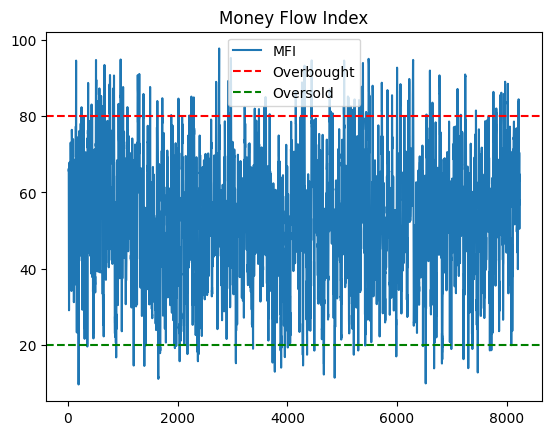

Price,Close,High,Low,Open,Volume,Typical_Price,Raw_Money_Flow,Price_Change,Pos_Flow,Neg_Flow,...,BB_SMA,BB_STD,Upper_Band,Lower_Band,MFI_Strategy,BB_Strategy,Full_Strategy,Strategy,Asset_Returns,Strategy_Returns
32,24.918278,25.039324,24.883693,25.039324,21800,24.947098,5.438467e+05,-0.149868,0.000000e+00,5.438467e+05,...,24.753992,0.409963,25.163955,24.344029,NaN,NaN,NaN,0,NaN,NaN
33,25.073910,25.177664,25.022033,25.022033,59300,25.091202,1.487908e+06,0.144104,1.487908e+06,0.000000e+00,...,24.806734,0.376964,25.183698,24.429770,0.0,0.0,0.0,0,0.006246,0.000000
34,25.035959,25.174951,25.035959,25.174951,66900,25.082290,1.678005e+06,-0.008912,0.000000e+00,1.678005e+06,...,24.853256,0.341629,25.194885,24.511627,0.0,0.0,0.0,0,0.004723,0.000000
35,24.896961,24.949083,24.775343,24.792717,183400,24.873796,4.561854e+06,-0.208494,0.000000e+00,4.561854e+06,...,24.888505,0.304118,25.192623,24.584386,0.0,0.0,0.0,0,-0.000855,0.000000
36,24.949085,24.983833,24.914337,24.966459,55200,24.949085,1.377190e+06,0.075289,1.377190e+06,0.000000e+00,...,24.927225,0.253546,25.180770,24.673679,0.0,0.0,0.0,0,0.001236,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8230,671.159973,673.940002,669.210022,673.530029,66501900,671.436666,4.465181e+10,-0.476664,0.000000e+00,4.465181e+10,...,664.354843,5.320908,669.675752,659.033935,0.0,-1.0,-1.0,0,25.934445,2.490831
8231,653.020020,673.950012,652.840027,672.130005,159422600,659.936686,1.052088e+11,-11.499980,0.000000e+00,1.052088e+11,...,664.226224,5.569165,669.795389,658.657059,0.0,-1.0,-1.0,0,25.206467,2.490831
8232,663.039978,665.130005,659.770020,660.650024,79560500,662.646667,5.272050e+10,2.709981,5.272050e+10,0.000000e+00,...,664.424088,5.445736,669.869823,658.978352,0.0,1.0,1.0,0,25.608580,2.490831
8233,662.229980,665.830017,653.169983,657.169983,88779600,660.409993,5.863094e+10,-2.236674,0.000000e+00,5.863094e+10,...,664.626825,5.273611,669.900436,659.353213,0.0,0.0,0.0,0,25.576073,2.490831


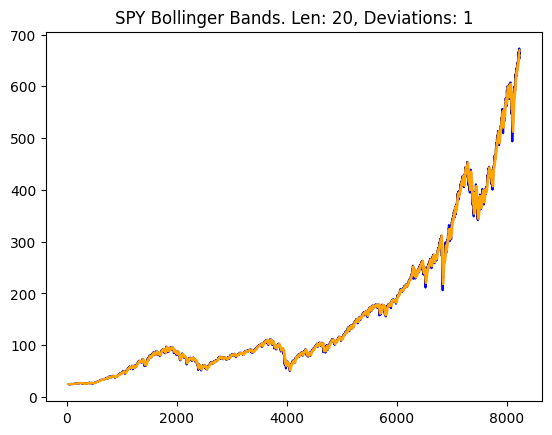

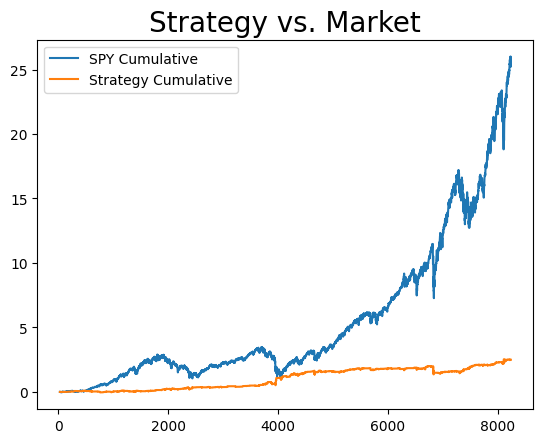

In [2]:
TICKER = 'SPY'
INTERVAL='1d'

# set period based on interval
if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'

MFI_LENGTH = 14
OVERBOUGHT = 70
OVERSOLD = 30
BB_LEN = 20
DEVS = 1


# what subsetion of that data are you interested in
LOOKBACK = 10000

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    # get data at interval you want
    df = yf.download(ticker, interval=interval, period=PERIOD)
    df.columns = df.columns.get_level_values(0)

    # reset the index to make plots prettier
    df = df.reset_index(drop=True)

    # only return the subset of data you are interested in
    return df.iloc[-lookback:, :]

def add_MFI(df, length=14, overbought=80, oversold=20):
    df = df.copy()

    # Step 1: Calculate typical price
    df['Typical_Price'] = (df['High'] + df['Low'] + df['Close']) / 3

    # Step 2: Calculate raw money flow
    df['Raw_Money_Flow'] = df['Typical_Price'] * df['Volume']

    # Step 3: Classify positive/negative money flow
    df['Price_Change'] = df['Typical_Price'].diff()

    df['Pos_Flow'] = np.where(df['Price_Change'] > 0, df['Raw_Money_Flow'], 0)
    df['Neg_Flow'] = np.where(df['Price_Change'] < 0, df['Raw_Money_Flow'], 0)

    # Step 4: Money Flow Ratio and MFI
    pos_sum = df['Pos_Flow'].rolling(window=length).sum()
    neg_sum = df['Neg_Flow'].rolling(window=length).sum()
    mfr = pos_sum / neg_sum
    df['MFI'] = 100 - (100 / (1 + mfr))

    # Step 5: Plot
    plt.figure()
    plt.plot(df['MFI'], label='MFI')
    plt.axhline(overbought, color='red', linestyle='--', label='Overbought')
    plt.axhline(oversold, color='green', linestyle='--', label='Oversold')
    plt.title('Money Flow Index')
    plt.legend()
    plt.show()

    return df.dropna()

def add_MFI_strategy(df, overbought=OVERBOUGHT, oversold=OVERSOLD):

    df['MFI_Strategy'] = 0
    df['MFI_Strategy'] = np.where(df['MFI'] > overbought, -1, 
                     np.where(df['MFI'] < oversold, 1, 0))
    
    # shift back to make sure we have seen the signal
    df['MFI_Strategy'] = df['MFI_Strategy'].shift(1)
    return df

def add_BB(df, devs=DEVS, bb_len=BB_LEN):

    # can change to ema (use MACD video/code for reference)
    df['BB_SMA'] = df['Close'].rolling(bb_len).mean()

    # get the standard deviation of the close prices for the period
    df['BB_STD'] = df['Close'].rolling(bb_len).std()

    df['Upper_Band'] = df['BB_SMA'] + (devs * df['BB_STD'])
    df['Lower_Band'] = df['BB_SMA'] - (devs * df['BB_STD'])

    df = df.dropna()

    plt.figure()
    plt.plot(df['Close'], color='blue')
    plt.plot(df['Upper_Band'], color='orange')
    plt.plot(df['Lower_Band'], color='orange')

    plt.title(f'{TICKER} Bollinger Bands. Len: {BB_LEN}, Deviations: {DEVS}');

    return df

def add_BB_strategy(df):
    df['BB_Strategy'] = 0
    df['BB_Strategy'] = np.where(
        df['Close'] > df['Upper_Band'], -1, 
        np.where(df['Close'] < df['Lower_Band'], 1, 0)
        )
    
    df['BB_Strategy'] = df['BB_Strategy'].shift(1)
    
    return df

def add_full_strategy(df):

    df['Full_Strategy'] = df['BB_Strategy'] + df['MFI_Strategy']

    # adjust values for simplicity
    df['Strategy'] = np.where(df['Full_Strategy'] == 2, 1, 
                     np.where(df['Full_Strategy'] == -2, -1, 0))

    return df

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.title('Strategy vs. Market', size='20')

    return df

def main():
    df = get_data()
    df = add_MFI(df)
    df = add_BB(df)
    df = add_MFI_strategy(df)
    df = add_BB_strategy(df)
    df = add_full_strategy(df)
    df = test_strategy(df)

    return df

df = main()
df